# Micrograd

Let's build Andrej Karpathy's Micrograd from scratch!

Steps:
1. Engine -> Value class ✅
2. Draw equations
3. Test manual gradient calculations
4. Automatic gradient
5. Neuron, layer and MLP classes



### Define "Value" class

In [ ]:
"""Value class
This class is the data structure for storing variables
of the code

Returns:
    Value: A new object with type Value
    
    TODO: MOVE TO SEPARATE MODULE
"""

from __future__ import annotations

import math


class Value:
    
    def __init__(self, data: float, name='', _prev=[], tag=None, _op=''):
        self.data = data
        self.grad = 0.0
        self.name = name
        self.tag = tag if tag else self.name
        self._op = _op
        self._prev = _prev
    
    def __repr__(self):
        return f"Value({self.name} | data={self.data}) | grad={self.grad} | tag={self.tag} | op={self._op} | children={[c.name for c in self._prev] if self._prev else []}"
    
    def __add__(self, other: Value) -> Value:
        self.grad += 1.0
        other.grad += 1.0
        return Value(self.data + other.data, tag=f"{self.name}+{other.name}", _op='+', _prev=[self, other])
    
    def __mul__(self, other: Value) -> Value:
        self.grad = other.data
        other.grad = self.data
        return Value(self.data * other.data, tag=f"{self.name}.{other.name}", _op='*', _prev=[self, other])
    
    def __pow__(self, other: Value) -> Value:
        return Value(self.data ** other.data, tag=f"{self.name}**{other.name}", _op='**', _prev=[self, other])
    
    def tanh(self):
        n = self.data
        out = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        self.grad = 1 - out**2
        return Value(out, tag=f"tanh({self.name})", _op="tanh", _prev=[self])
    
    def sigmoid(self):
        n = self.data
        out = 1 / (1 + math.exp(-n))
        self.grad = out * (1 - out)
        return Value(out, tag=f"sig({self.name})", _op="sig", _prev=[self])
    
    def relu(self):
        n = self.data
        if n > 0:
            out = n
            self.grad = 1
        elif n < 0:
            out = 0.0
            self.grad = 0
        else:
            out = 0.0
            self.grad = 0.5
        return Value(out, tag=f"relu({self.data})", _op="relu", _prev=[self])
            
    # backpropagation - apply chain-rule
    def backward(self): 
        for c in self._prev:
            c.grad = self.grad * c.grad
            c.backward()

In [78]:
# utils.py
import graphviz


def trace(root) -> tuple[set[Value, set[Value]]]:
    nodes, edges = set(), set()
    def build(n: Value):
        nodes.add(n)
        for child in n._prev:
            edges.add((child, n))
            build(child)
    build(root)
    return nodes, edges
        
            
def print_tree(root):
    nodes, edges = trace(root)
    print("========= NODES ===========")
    for ind, val in enumerate(nodes):
        print(f"{ind} - {val}")
    print(" ========== EDGES =========")
    for ind, (t, h) in enumerate(edges):
        print(f"{ind} - ({t.name}, {h.name})")
      
def draw_computation_graph(root: Value) -> graphviz.Digraph:
    dot = graphviz.Digraph('computation_graph', comment='Graph of Computations', graph_attr={'rankdir': 'LR'}, format='SVG')
    nodes, edges = trace(root)
    for n in nodes:
        dot.node(name=str(id(n)), label=f"{{{n.name} | data={n.data:.4f} | grad={n.grad:.4f} }}", shape='record')    
        if n._op:
            dot.node(name=str(id(n))+n._op, label=n._op)
            dot.edge(tail_name=str(id(n))+n._op, head_name=str(id(n)))
    for tail, head in edges:
        dot.edge(tail_name=str(id(tail)), head_name=str(id(head)) + head._op)
    return dot
        


test the Value class

In [79]:
a = Value(4.5, 'a')
b = Value(2.75, 'b')
print(a)
print(a + b)
print(a * b)
print(a**b)

Value(a | data=4.5) | grad=0.0 | tag=a | op= | children=[]
Value( | data=7.25) | grad=0.0 | tag=a+b | op=+ | children=['a', 'b']
Value( | data=12.375) | grad=0.0 | tag=a.b | op=* | children=['a', 'b']
Value( | data=62.5654269961787) | grad=0.0 | tag=a**b | op=** | children=['a', 'b']


## Draw Computation Diagram

To use graphviz, it's necessary to install the system software on the OS as wells as the python package.

- `$ sudo apt install graphviz`

- `$ pip install graphviz`

In [80]:
a = Value(4.5, 'a')
b = Value(2.75, 'b')
c = Value(5.3, 'c')
d = Value(4.0, 'd')
h1 = a + b; h1.name = 'h1'
h2 = h1 * c; h2.name = 'h2'
h3 = h2 ** d; h3.name = 'h3'

In [81]:
a = Value(4.5, 'a')
b = Value(2.75, 'b')
c = Value(5.3, 'c')
d = Value(4.0, 'd')
h1 = a + b; h1.name = 'h1'
h2 = h1 * c; h2.name = 'h2'
h3 = h2 ** d; h3.name = 'h3'

In [82]:
trace(h3)
print_tree(h3)

========= NODES ===========
0 - Value(d | data=4.0) | grad=0.0 | tag=d | op= | children=[]
1 - Value(h2 | data=38.425) | grad=0.0 | tag=h1.c | op=* | children=['h1', 'c']
2 - Value(h1 | data=7.25) | grad=5.3 | tag=a+b | op=+ | children=['a', 'b']
3 - Value(h3 | data=2179995.03600039) | grad=0.0 | tag=h2**d | op=** | children=['h2', 'd']
4 - Value(b | data=2.75) | grad=1.0 | tag=b | op= | children=[]
5 - Value(c | data=5.3) | grad=7.25 | tag=c | op= | children=[]
6 - Value(a | data=4.5) | grad=1.0 | tag=a | op= | children=[]
 ========== EDGES =========
0 - (h1, h2)
1 - (a, h1)
2 - (h2, h3)
3 - (c, h2)
4 - (b, h1)
5 - (d, h3)


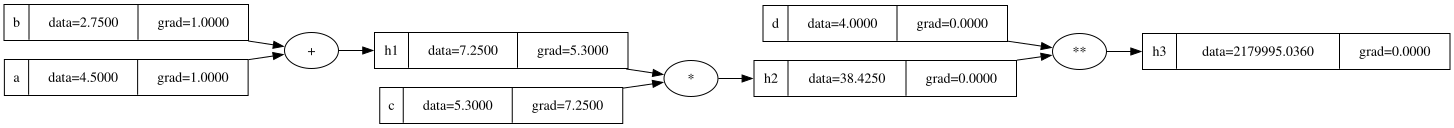

In [83]:
draw_computation_graph(h3)

## Calculating Gradients

Compute gradients manually and test the propagation of the gradients in the computation graph

Let's define a new set of equations for testing the following testings

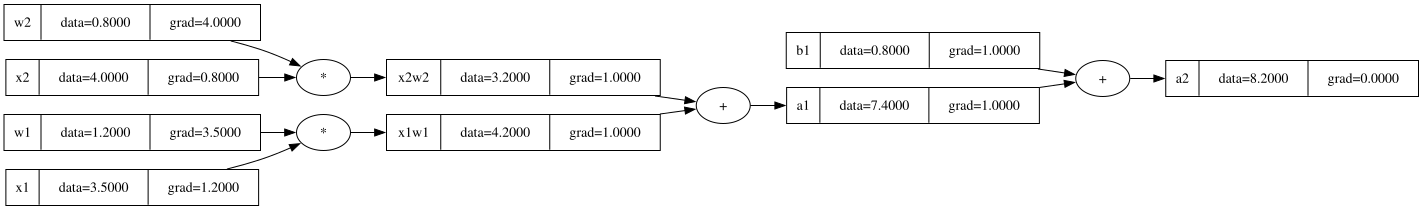

In [84]:
def test_compute():
    x1 = Value(3.5, 'x1')
    w1 = Value(1.2, 'w1')
    x1w1 = x1 * w1; x1w1.name = 'x1w1'
    x2 = Value(4.0, 'x2')
    w2 = Value(0.8, 'w2')
    x2w2 = x2 * w2; x2w2.name = 'x2w2'
    a1 = x1w1 + x2w2; a1.name = 'a1'
    b1 = Value(0.8, 'b1')
    a2 = a1 + b1; a2.name = 'a2'
    return draw_computation_graph(a2)

test_compute()

Let's define gradients

d(a2)/d(a1) =  0.9999999999994458


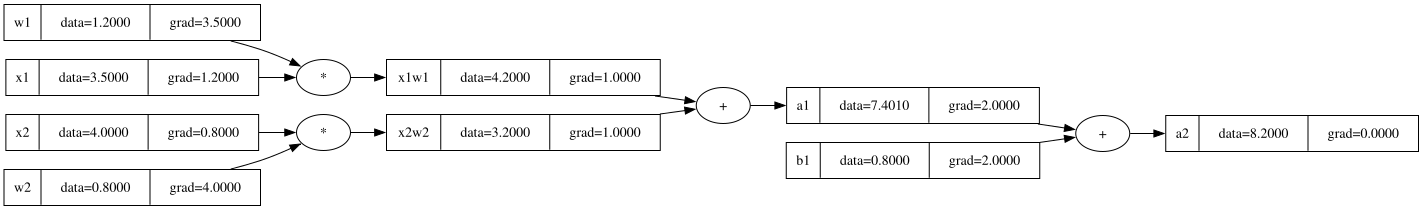

In [85]:
def test_compute():
    h = 0.001
    
    x1 = Value(3.5, 'x1')
    w1 = Value(1.2, 'w1')
    x1w1 = x1 * w1; x1w1.name = 'x1w1'
    x2 = Value(4.0, 'x2')
    w2 = Value(0.8, 'w2')
    x2w2 = x2 * w2; x2w2.name = 'x2w2'
    a1 = x1w1 + x2w2; a1.name = 'a1'
    b1 = Value(0.8, 'b1')
    
    a2 = a1 + b1; a2.name = 'a2'
    a1.data += h
    a2_eps = a1 + b1; a2_eps.name = "a2_eps"
    
    g = (a2_eps.data - a2.data) / h
    print("d(a2)/d(a1) = ", g)
    return draw_computation_graph(a2)

test_compute()

### Youtube video example 1


dL/da = 6.000000000000227
a.grad =  6.0


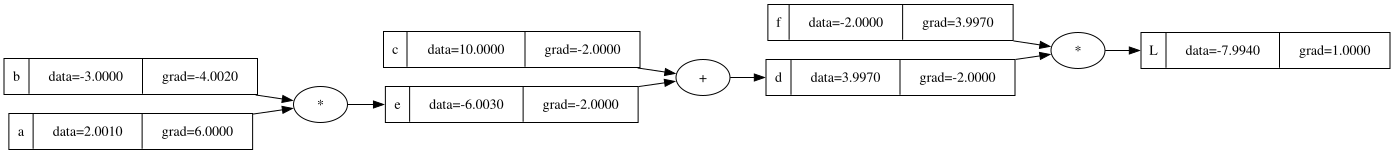

In [ ]:
def test_compute():
    h = 0.001
    
    a = Value(2.0, name='a')
    b = Value(-3.0, name='b')
    c = Value(10.0, name='c')
    e = a * b; e.name = 'e'
    d = e + c; d.name = 'd'
    f = Value(-2.0, name='f')
    L = d * f; L.name = 'L'
    L1 = L.data
    
    # modifying variables
    a = Value(2.0, name='a')
    a.data += h
    b = Value(-3.0, name='b')
    c = Value(10.0, name='c')
    e = a * b; e.name = 'e'
    d = e + c; d.name = 'd'
    f = Value(-2.0, name='f')
    L = d * f; L.name = 'L';
    L2 = L.data
    
    L.grad = 1.0
    
    print("dL/da =", (L2 - L1) / h)
    L.backward()
    print("a.grad = ", a.grad)
    return draw_computation_graph(L)
test_compute()

### Youtube Video Example 2 - Neuron

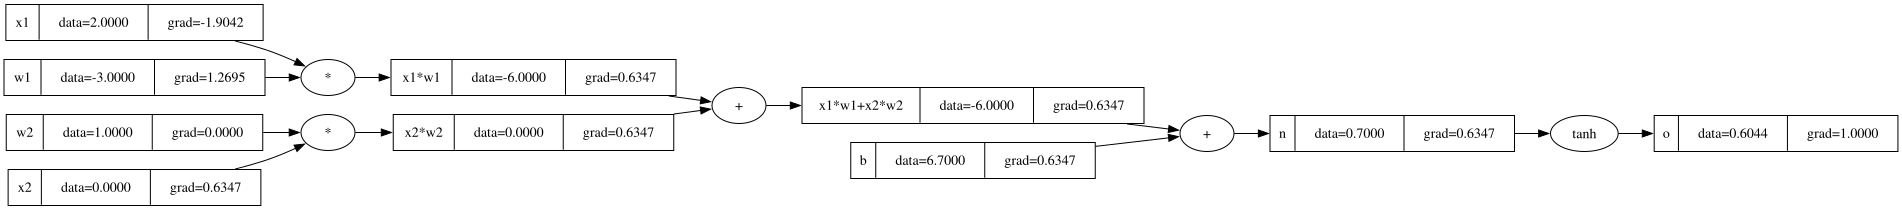

In [ ]:
def test_compute():
    x1 = Value(2.0, name='x1')
    x2 = Value(0.0, name='x2')
    w1 = Value(-3.0, name='w1')
    w2 = Value(1.0, name='w2')
    b = Value(6.7, name='b')
    x1w1 = x1 * w1; x1w1.name = 'x1*w1'
    x2w2 = x2 * w2; x2w2.name = 'x2*w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.name = 'x1*w1+x2*w2'
    n = x1w1x2w2 + b; n.name = 'n'
    o = n.tanh(); o.name = 'o'
    
    o.grad = 1.0
    o.backward()
    return draw_computation_graph(o)

test_compute()

Second check on the value of the gradient by comparing the gradient calculated by backprop and the manually-calculated gradients

dO/dx2 =  0.6343559942085797


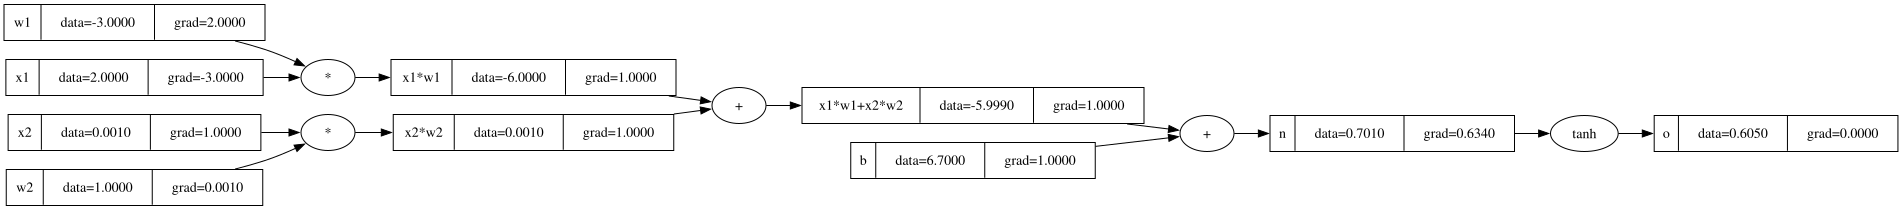

In [ ]:
def test_compute():
    h = 0.001
    
    x1 = Value(2.0, name='x1')
    x2 = Value(0.0, name='x2')
    w1 = Value(-3.0, name='w1')
    w2 = Value(1.0, name='w2')
    b = Value(6.7, name='b')
    x1w1 = x1 * w1; x1w1.name = 'x1*w1'
    x2w2 = x2 * w2; x2w2.name = 'x2*w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.name = 'x1*w1+x2*w2'
    n = x1w1x2w2 + b; n.name = 'n'
    o = n.tanh(); o.name = 'o'
    L1 = o.data
    
    # Modifying variables
    x1 = Value(2.0, name='x1')
    x2 = Value(0.0, name='x2')
    x2.data += h
    w1 = Value(-3.0, name='w1')
    w2 = Value(1.0, name='w2')
    b = Value(6.7, name='b')
    x1w1 = x1 * w1; x1w1.name = 'x1*w1'
    x2w2 = x2 * w2; x2w2.name = 'x2*w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.name = 'x1*w1+x2*w2'
    n = x1w1x2w2 + b; n.name = 'n'
    o = n.tanh(); o.name = 'o'
    L2 = o.data
    
    print("dO/dx2 = ", (L2 - L1) / h)
    
    return draw_computation_graph(o)

test_compute()

As you can see, the derivative of the O with respect to x2, is the same as the gradient calculated by the backpropagation.

### Youtube Example 3 - Nicely shaped outputs!

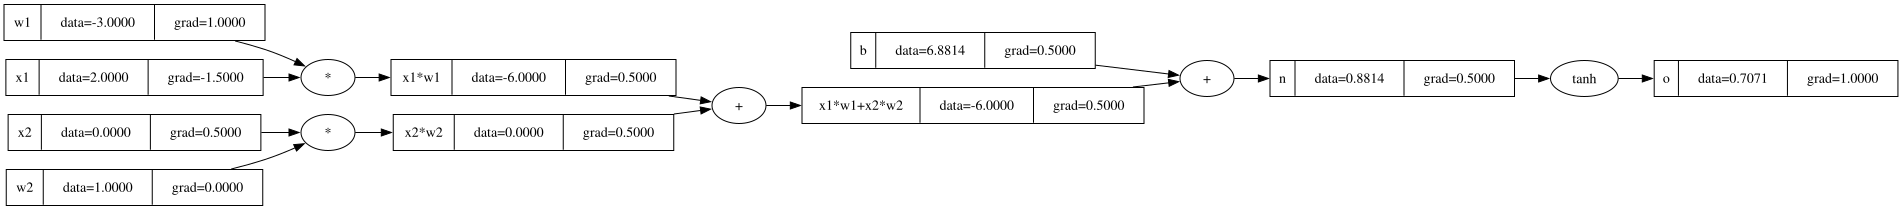

In [93]:
def test_compute():
    x1 = Value(2.0, name='x1')
    x2 = Value(0.0, name='x2')
    w1 = Value(-3.0, name='w1')
    w2 = Value(1.0, name='w2')
    b = Value(6.8813735870195432, name='b')
    x1w1 = x1 * w1; x1w1.name = 'x1*w1'
    x2w2 = x2 * w2; x2w2.name = 'x2*w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.name = 'x1*w1+x2*w2'
    n = x1w1x2w2 + b; n.name = 'n'
    o = n.tanh(); o.name = 'o'
    
    o.grad = 1.0
    o.backward()
    return draw_computation_graph(o)

test_compute()